 # Chapter 3: The DeepSeek Breakthrough: Multi-Head Latent Attention (MLA)

## Multi-Head Latent Attention: The Key to Efficiency at Scale

MLA was introduced in DeepSeek-V2 and subsequently used in DeepSeek-V3. Its central goal is:

> **Compress the information needed for K and V into a small latent vector, cache that latent instead of full per-head K/V tensors, and reconstruct the necessary representations when performing attention**

DeepSeek V3 models represent a significant advancement in large language model architecture, particularly in how they handle attention mechanisms. With a staggering 671B total parameters (37B activated), DeepSeek requires innovative approaches to maintain efficiency without sacrificing quality.

This chapter explores the central innovation of DeepSeek's architecture: **Multi-Head Latent Attention (MLA)**. Building upon the key-value cache concepts we explored in Chapter 2, MLA takes efficiency to the next level by compressing key-value pairs into a shared latent space.

## 3.1 The Challenge: Memory Constraints in Large-Scale Models

Before diving into Multi-Head Latent Attention, let's revise the problem it solves.

### The KV Cache Memory Problem

As we saw in Chapter 2, the key-value cache dramatically improves inference speed by storing previously computed key-value pairs. However, this introduces a new challenge: **memory consumption**.

For models like DeepSeek-V2 with:
- 21B activated parameters (out of 236B total)
- 128K token context window  
- 128 attention heads

The memory required for the KV cache becomes enormous:

$$\text{Memory} = \text{batch size} \times \text{sequence length} \times \text{number of heads} \times \text{head dimension} \times \text{bytes per parameter} \times 2$$

For example, with 128 attention heads, a head dimension of 128, and 16-bit precision:
- A 4K context requires ~0.24GB per batch item
- A 128K context requires ~7.8GB per batch item

This quickly becomes impractical for deployment, especially in consumer hardware.

### Previous Solutions Were Insufficient

Previous approaches like MQA and GQA reduced memory by sharing key-value projections across heads, but they came with quality tradeoffs. DeepSeek needed something better to maintain quality while scaling to 128K context.

## 3.2 Multi-Head Latent Attention: The Core Innovation

Multi-Head Latent Attention (MLA) is DeepSeek's breakthrough solution to the KV cache memory problem. The core insight is elegantly simple:

> **"Compress for storage, decompress for use."**

### The MLA Architecture

MLA introduces a new flow for key-value computation:

1. **Down-Projection**: Project the input embedding into a compressed latent space
2. **Storage**: Store only this compressed representation in the KV cache
3. **Up-Projection**: When needed, reconstruct the full-sized key and value matrices on the fly

This approach offers two major benefits:
- **Dramatically reduced memory footprint**: Only the compact latent representation is stored
- **Preserved model quality**: The reconstruction preserves the expressiveness of full attention

### Mathematical Formulation

Let's denote:
- $X$ as the input embeddings
- $d_{model}$ as the model dimension (e.g., 4096)
- $d_{latent}$ as the latent dimension (e.g., 256)

The standard attention computes and stores:
$K = XW_K$ and $V = XW_V$

MLA instead computes and stores:
$C_{KV} = XW_{down}$ (where $W_{down}$ projects to $d_{latent}$)

And reconstructs as needed:
$K = C_{KV}W_{up_K}$ and $V = C_{KV}W_{up_V}$

The memory savings can be substantial: if $d_{latent}$ is 8x smaller than the head dimensions, the KV cache size is reduced by ~8x.

## Listing 3.1: Building the MLA Module from Scratch

The following code implements a Multi-Head Latent Attention layer from scratch, demonstrating the core "compress-decompress" mechanism:

In [1]:
# ==================================================
# LISTING 3.1: Building the MLA Module from Scratch
# ==================================================

import torch
import torch.nn as nn

class MultiHeadLatentAttention(nn.Module):
    """
    Implementation of Multi-Head Latent Attention (MLA) as described
    in the DeepSeek architecture. This version focuses on the core
    "compress for storage, decompress for use" mechanism for the
    Key and Value matrices.
    """
    def __init__(self, d_model, num_heads, d_latent, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads
        self.d_latent = d_latent # The dimension of the compressed latent space

        # The Query projection remains standard, projecting to the full model dimension.
        self.W_q = nn.Linear(d_model, d_model)          # Query Projection

        # The new KV Down-Projector. This is the "compress" step.
        # It projects the input down to a small, shared latent space.
        self.W_dkv = nn.Linear(d_model, d_latent)       # Compress into Latent KV Space

        # The new Key and Value Up-Projectors. This is the "decompress" step.
        # They reconstruct the full-sized K and V from the latent space.
        # Note: These are multi-headed to preserve head diversity.
        self.W_uk = nn.Linear(d_latent, d_model)        # Decompress K
        self.W_uv = nn.Linear(d_latent, d_model)        # Decompress V

        # The final output projection, standard for multi-head attention.
        self.W_o = nn.Linear(d_model, d_model)          # Final Output Projection

        self.dropout = nn.Dropout(dropout)
        # Causal mask to prevent attending to future tokens. Using a fixed size for demo.
        self.register_buffer('mask', torch.triu(
            torch.ones(1, 1, 1024, 1024), diagonal=1).bool())

    def forward(self, x):
        batch_size, seq_len, _ = x.shape

        # 1. Query Path (Unchanged)
        # Project and reshape the query as in standard MHA.
        q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.d_head).transpose(1, 2)

        # 2. Key/Value Path (The MLA Innovation)
        # Step 2a: Down-Project to the latent space.
        # This is the ONLY value that would be cached during inference.
        c_kv = self.W_dkv(x) # Shape: (batch, seq_len, d_latent)

        # Step 2b: Up-Project from the latent space to get full K and V.
        # These are computed on the fly and are not cached.
        k = self.W_uk(c_kv).view(batch_size, seq_len, self.num_heads, self.d_head).transpose(1, 2)
        v = self.W_uv(c_kv).view(batch_size, seq_len, self.num_heads, self.d_head).transpose(1, 2)

        # 3. Standard Attention Calculation
        # The rest of the process is identical to standard MHA.
        attn_scores = (q @ k.transpose(-2, -1)) / (self.d_head ** 0.5)

        # Apply causal mask
        attn_scores = attn_scores.masked_fill(
            self.mask[:, :, :seq_len, :seq_len], float('-inf'))

        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vector = (attn_weights @ v).transpose(1, 2).contiguous().view(
            batch_size, seq_len, self.d_model)

        # 4. Final Output Projection
        output = self.W_o(context_vector)
        return output

# --- Usage Example ---
d_model = 512
num_heads = 8
d_latent = 128  # Latent dimension must be smaller than d_model
batch_size = 4
seq_len = 64

# Instantiate the layer
mla_layer = MultiHeadLatentAttention(d_model, num_heads, d_latent)

# Create a dummy input tensor
dummy_input = torch.randn(batch_size, seq_len, d_model)

# Pass the input through the layer
output = mla_layer(dummy_input)

print("✅ MLA Layer successful! 🎆")
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")

✅ MLA Layer successful! 🎆
Input shape: torch.Size([4, 64, 512])
Output shape: torch.Size([4, 64, 512])


### Understanding the MLA Implementation

Let's break down the key components of our Multi-Head Latent Attention implementation:

1. **Regular Query Projection**:
   ```python
   self.W_q = nn.Linear(d_model, d_model)
   ```
   The query projection remains standard, preserving full expressiveness.

2. **Down-Projection for Compression**:
   ```python
   self.W_dkv = nn.Linear(d_model, d_latent)
   ```
   This is where the magic happens: compressing the input to a much smaller latent space.

3. **Up-Projections for Reconstruction**:
   ```python
   self.W_uk = nn.Linear(d_latent, d_model)
   self.W_uv = nn.Linear(d_latent, d_model)
   ```
   These reconstruct the full-sized Key and Value matrices on demand.

4. **The Forward Path**:
   - `c_kv = self.W_dkv(x)`: The compressed representation (what gets cached)
   - `k = self.W_uk(c_kv)`: On-the-fly reconstruction of Key matrix
   - `v = self.W_uv(c_kv)`: On-the-fly reconstruction of Value matrix

This architecture means that during inference:
- For each token, we only store the compact `c_kv` representation in the KV cache
- We compute the full K and V matrices only when needed for attention computation

**Memory Efficiency**: For a model with d_model=4096 and d_latent=256, we reduce the KV cache size by 16x compared to standard attention!

## Let's Perform Some Experimentats and Tests for MLA

### Step 1: Writing the code for the Multi-Head Latent Attention Without Rotary Position Embeddings (RoPE)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RopelessMLA(nn.Module):
    def __init__(self, d_model, n_heads, kv_latent_dim):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.dh = d_model // n_heads  # dimension per head

        # Projection layers
        self.W_q = nn.Linear(d_model, d_model, bias=False)             # Query projection
        self.W_dkv = nn.Linear(d_model, kv_latent_dim, bias=False)     # Compress into latent KV space
        self.W_uk = nn.Linear(kv_latent_dim, d_model, bias=False)      # Decompress K
        self.W_uv = nn.Linear(kv_latent_dim, d_model, bias=False)      # Decompress V
        self.W_o = nn.Linear(d_model, d_model, bias=False)             # Final output projection

        self.ln = nn.LayerNorm(kv_latent_dim)                          # Layer normalization for latent KV space
        self.register_buffer('absorbed_k', None)                       # Holds W_q @ W_uk

    def forward(self, x, kv_cache=None, past_length=0):
        B, S, D = x.size()            # Batch_Size, Sequence_Length, d_model

        # Compute absorbed_k once: W_q @ W_uk, shape: (D, latent_dim)
        if self.absorbed_k is None:
            absorbed = torch.matmul(self.W_q.weight, self.W_uk.weight)    # (D, latent_dim)
            self.absorbed_k = absorbed.view(self.n_heads, self.dh, -1)    # (n_heads, dh, latent_dim)

        # Compress x into latent KV space
        new_c_kv = self.ln(self.W_dkv(x))                                         # (B, S, latent_dim)
        if kv_cache is None:
            c_kv = new_c_kv
        else:
            c_kv = torch.cat([kv_cache, new_c_kv], dim=1)                 # (B, S_total, latent_dim)

        S_full = c_kv.size(1)

        # Decompress V to full d_model and split into heads
        v_full = self.W_uv(c_kv)                                                  # (B, S_full, D)
        v = v_full.view(B, S_full, self.n_heads, self.dh).transpose(1, 2)         # (B, n_heads, S_full, dh)

        # Use input x directly (since W_q is absorbed)
        q = x.view(B, S, self.n_heads, self.dh)                                   # (B, S, n_heads, dh)

        # Compute attention scores
        attn_scores = torch.zeros(B, self.n_heads, S, S_full, device=x.device)
        for h in range(self.n_heads):
            tmp = torch.matmul(q[:, :, h], self.absorbed_k[h])            # (B, S, latent_dim)
            ## BMM -> Performs a batch matrix-matrix product or parallel multiplication for
            ## Absorbed Query Vector by New Compressed KV Transpose
            attn_scores[:, h] = torch.bmm(tmp, c_kv.transpose(1, 2))              # (B, S, S_full)

        # Scale and apply causal mask
        attn_scores = attn_scores / (self.dh ** 0.5)
        mask = torch.tril(torch.ones((S, S_full), device=x.device), diagonal=past_length)
        attn_scores = attn_scores.masked_fill(mask.view(1, 1, S, S_full) == 0, float('-inf'))

        # Softmax to get attention weights
        attn_weights = F.softmax(attn_scores, dim=-1)                     # (B, n_heads, S, S_full)

        # Apply attention weights to each head's V separately
        out_heads = []
        for h in range(self.n_heads):
            context_h = torch.matmul(attn_weights[:, h], v[:, h])         # (B, S, dh)
            out_heads.append(context_h)

        # Concatenate all head outputs along the feature dimension
        out = torch.cat(out_heads, dim=-1)                                # (B, S, D)

        # Final output projection + updated latent cache
        return self.W_o(out), c_kv

### Step 2: Memory Testing

In [3]:
# ===================================================
# ============ Demo for Memory Testing ==============
# ===================================================

def demo_memory_testing():
    model = RopelessMLA(d_model=512, n_heads=8, kv_latent_dim=256)
    x = torch.randn(1, 5, 512)                     # Batch=2, Sequence=10, d_model=512

    out, cache = model(x)
    print(f"Output: {out.shape}, Cache: {cache.shape}")

    # Memory comparison
    std_size = 2 * 2 * 10 * 512 * 4 / 1024          # KB (standard KV: B * 2 (K,V) * T * D * float32)
    latent_size = 1*2 * 10 * 256 * 4 / 1024         # KB (latent cache: B * T * latent_dim * float32)
    print(f"Memory: Standard={std_size:.1f}KB, Latent={latent_size:.1f}KB, Reduction={std_size/latent_size:.1f}x🚀")


if __name__ == "__main__":
    demo_memory_testing()

Output: torch.Size([1, 5, 512]), Cache: torch.Size([1, 5, 256])
Memory: Standard=80.0KB, Latent=20.0KB, Reduction=4.0x🚀


### Step 3: Cache Testing - Single New Inference

In [5]:
# ===================================================
# ============ Demo for Cache Testing ===============
# ============= Single New Inference ================
# ===================================================

def demo_cache_usage():
    torch.manual_seed(0)

    model = RopelessMLA(d_model=8, n_heads=2, kv_latent_dim=4)

    # ---- Step 1: Initial input (sequence of 5 tokens) ----
    x1 = torch.randn(1, 5, 8)                            # (B=1, S=5, D=8)
    out1, cache1 = model(x1)

    print("‼️Step 1: Initial input:")
    print(f"\tOutput shape: {out1.shape}")
    print(f"\tCache shape:  {cache1.shape}")                       # Expect: (1, 5, 4)

    # ---- Step 2: Append 1 token ----
    x2 = torch.randn(1, 1, 8)                            # (B=1, S=1, D=8)
    out2, cache2 = model(x2, kv_cache=cache1, past_length=5)

    print("\n❗Step 2: New token Comes in:")
    print(f"\tOutput shape: {out2.shape}")
    print(f"\tCache shape:  {cache2.shape}")                       # Expect: (1, 6, 4)


if __name__ == "__main__":
    demo_cache_usage()

‼️Step 1: Initial input:
	Output shape: torch.Size([1, 5, 8])
	Cache shape:  torch.Size([1, 5, 4])

❗Step 2: New token Comes in:
	Output shape: torch.Size([1, 1, 8])
	Cache shape:  torch.Size([1, 6, 4])


### Step 4: Cache testing - Multiple new inferences

In [6]:
# ===================================================
# ============ Demo for Cache Testing ===============
# ============ Multiple New Inference ===============
# ===================================================

def demo_kv_cache_growth(num_initial_tokens=5, num_new_tokens=3):
    torch.manual_seed(0)

    model = RopelessMLA(d_model=8, n_heads=2, kv_latent_dim=4)

    # Step 1: Start with initial token batch
    x = torch.randn(1, num_initial_tokens, 8)
    out, cache = model(x)
    print(f"Step 0️⃣: Initial input of {num_initial_tokens} tokens → cache shape: {cache.shape}")

    # Step 2: Incrementally append new tokens one at a time
    for step in range(1, num_new_tokens + 1):
        new_token = torch.randn(1, 1, 8)    # (B=1, S=1, D=8)
        out, cache = model(new_token, kv_cache=cache, past_length=cache.shape[1])
        print(f"Step {step}: Added 1 token → cache shape: {cache.shape}")

demo_kv_cache_growth(num_initial_tokens=50, num_new_tokens=4)


Step 0️⃣: Initial input of 50 tokens → cache shape: torch.Size([1, 50, 4])
Step 1: Added 1 token → cache shape: torch.Size([1, 51, 4])
Step 2: Added 1 token → cache shape: torch.Size([1, 52, 4])
Step 3: Added 1 token → cache shape: torch.Size([1, 53, 4])
Step 4: Added 1 token → cache shape: torch.Size([1, 54, 4])


### Step 5: Visualizing W_q, W_uk and W_uv matrices for different heads

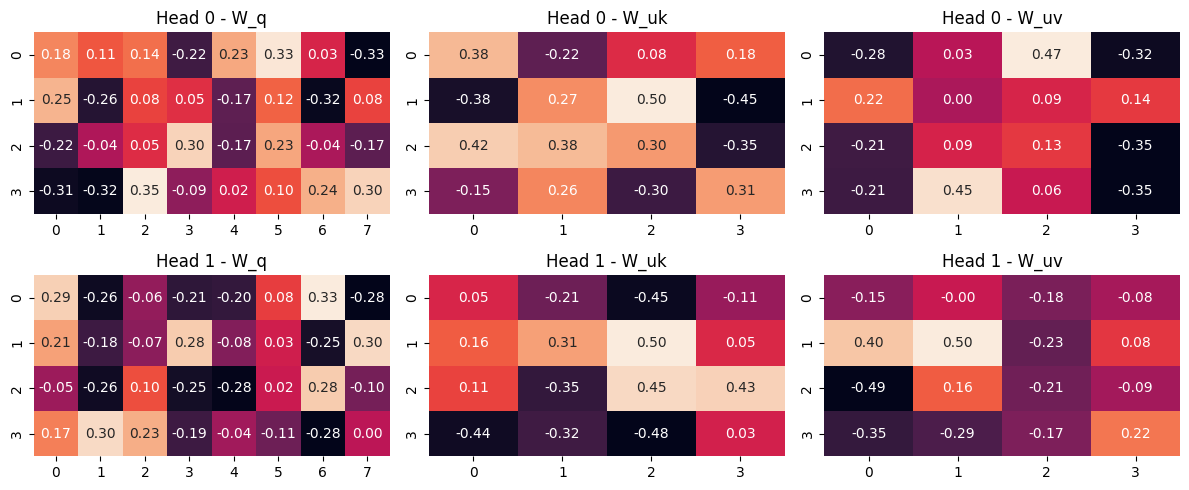

In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns


class RopelessMLA(nn.Module):
    def __init__(self, d_model=8, n_heads=2, kv_latent_dim=4):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.dh = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_uk = nn.Linear(kv_latent_dim, d_model, bias=False)
        self.W_uv = nn.Linear(kv_latent_dim, d_model, bias=False)


model = RopelessMLA()


## Extract weights
W_q = model.W_q.weight.detach().numpy()
W_uk = model.W_uk.weight.detach().numpy()
W_uv = model.W_uv.weight.detach().numpy()


## Split per head
n_heads = model.n_heads
dh = model.dh
W_q_heads = W_q.reshape(n_heads, dh, -1)
W_uk_heads = W_uk.T.reshape(n_heads, dh, -1)
W_uv_heads = W_uv.T.reshape(n_heads, dh, -1)


## Plot heatmaps
fig, axes = plt.subplots(n_heads, 3, figsize=(12, 5))
for h in range(n_heads):
    sns.heatmap(W_q_heads[h], ax=axes[h, 0], cbar=False, annot=True, fmt=".2f")
    axes[h, 0].set_title(f"Head {h} - W_q")

    sns.heatmap(W_uk_heads[h], ax=axes[h, 1], cbar=False, annot=True, fmt=".2f")
    axes[h, 1].set_title(f"Head {h} - W_uk")

    sns.heatmap(W_uv_heads[h], ax=axes[h, 2], cbar=False, annot=True, fmt=".2f")
    axes[h, 2].set_title(f"Head {h} - W_uv")


plt.tight_layout()
plt.show()